# Home Loan Approval — Data Analytics with AI

**Student:** Tharun Kumar Varma Chekuri  
**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship Program (BharatCares in association with AICTE)  
**Project:** Home Loan Approval

This notebook follows the internship brief in order: problem definition, hypothesis generation, data preparation, EDA, evaluation metrics, baseline models, feature engineering, tuned models, test prediction, and conclusion.

## 1. Problem Statement

Dream Housing Finance wants to automate the home-loan eligibility process using customer application details. The supplied brief states that the system should use applicant information such as gender, marital status, education, dependents, income, loan amount, credit history and other application attributes to identify customers eligible for a loan. The target variable is **Loan_Status**, with `Y` representing approval and `N` representing non-approval.

The objective is to build a reproducible binary classification workflow and generate a `submission.csv` containing `Loan_ID` and predicted `Loan_Status`.

## 2. Hypothesis Generation

Before modeling, the following hypotheses are tested through EDA:

1. Applicants with a positive **Credit_History** are more likely to receive approval.
2. Higher **ApplicantIncome** and/or **TotalIncome** may improve approval probability.
3. Higher **LoanAmount** may reduce approval probability because the requested exposure is larger.
4. **Education** may be associated with approval status.
5. Applicants from different **Property_Area** categories may have different approval rates.
6. **Marital status** and **dependents** may be associated with loan approval through household financial structure.

These are hypotheses, not assumptions about the final model; the data and validation metrics determine whether they are useful.

## 3. Getting the System Ready and Loading the Data

The notebook uses relative paths so it can run from the repository root. The train file contains the target; the test file does not.

**Dataset source:** Kaggle — [Home Loan Approval](https://www.kaggle.com/datasets/rishikeshkonapure/home-loan-approval/data) by `rishikeshkonapure`.

The CSV files used in this notebook are the uploaded copies of that dataset. The notebook reads them locally from the repository `data/` directory.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report
)

RANDOM_STATE = 42
ROOT = Path(".")
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / "loan_sanction_train.csv")
test = pd.read_csv(DATA_DIR / "loan_sanction_test.csv")

print("Training shape:", train.shape)
print("Test shape:", test.shape)
display(train.head())


Training shape: (614, 13)
Test shape: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 4. Understanding the Data

The first inspection covers shape, data types, descriptive statistics, and missing values. The identifier `Loan_ID` is retained for the final submission but is not used as a predictive feature.

In [2]:
print("Training shape:", train.shape)
print("Test shape:", test.shape)

print("\nData types:")
display(train.dtypes.to_frame("dtype"))

print("\nDescriptive statistics:")
display(train.describe(include="all").T)

print("\nMissing values:")
missing = pd.DataFrame({
    "Train Missing": train.isna().sum(),
    "Train Missing %": (train.isna().mean()*100).round(2),
    "Test Missing": test.isna().sum(),
    "Test Missing %": (test.isna().mean()*100).round(2)
})
display(missing)


Training shape: (614, 13)
Test shape: (367, 12)

Data types:


,dtype
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0



Missing values:


,Train Missing,Train Missing %,Test Missing,Test Missing %
ApplicantIncome,0,0.00,0.0,0.00
CoapplicantIncome,0,0.00,0.0,0.00
Credit_History,50,8.14,29.0,7.90
Dependents,15,2.44,10.0,2.72
Education,0,0.00,0.0,0.00
Gender,13,2.12,11.0,3.00
LoanAmount,22,3.58,5.0,1.36
Loan_Amount_Term,14,2.28,6.0,1.63
Loan_ID,0,0.00,0.0,0.00
Loan_Status,0,0.00,NaN,NaN


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target and Univariate Analysis

Categorical variables are examined with count plots and numerical variables with histograms/box plots. The target distribution is reported so that class imbalance is handled transparently rather than hidden.

Loan status distribution:


,Count,Percent
Loan_Status,,
Y,422,68.73
N,192,31.27


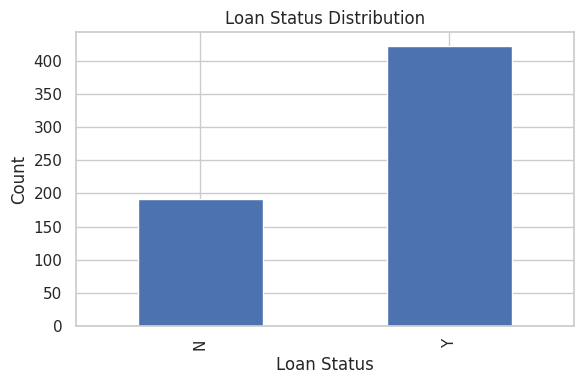

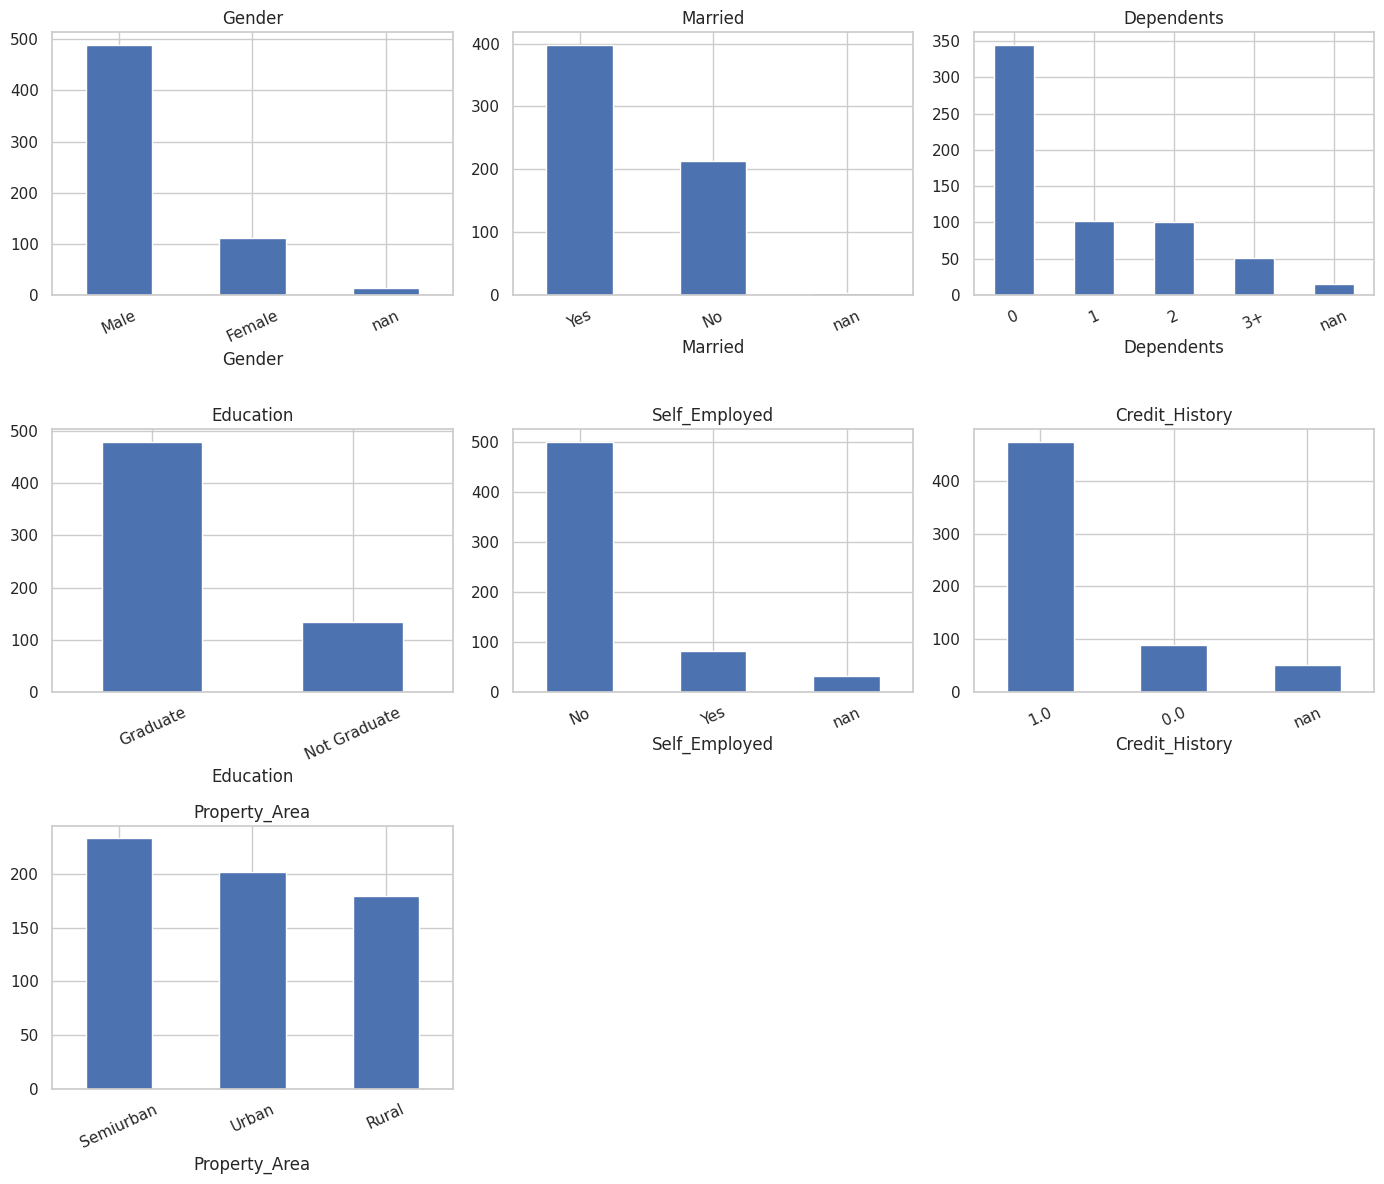

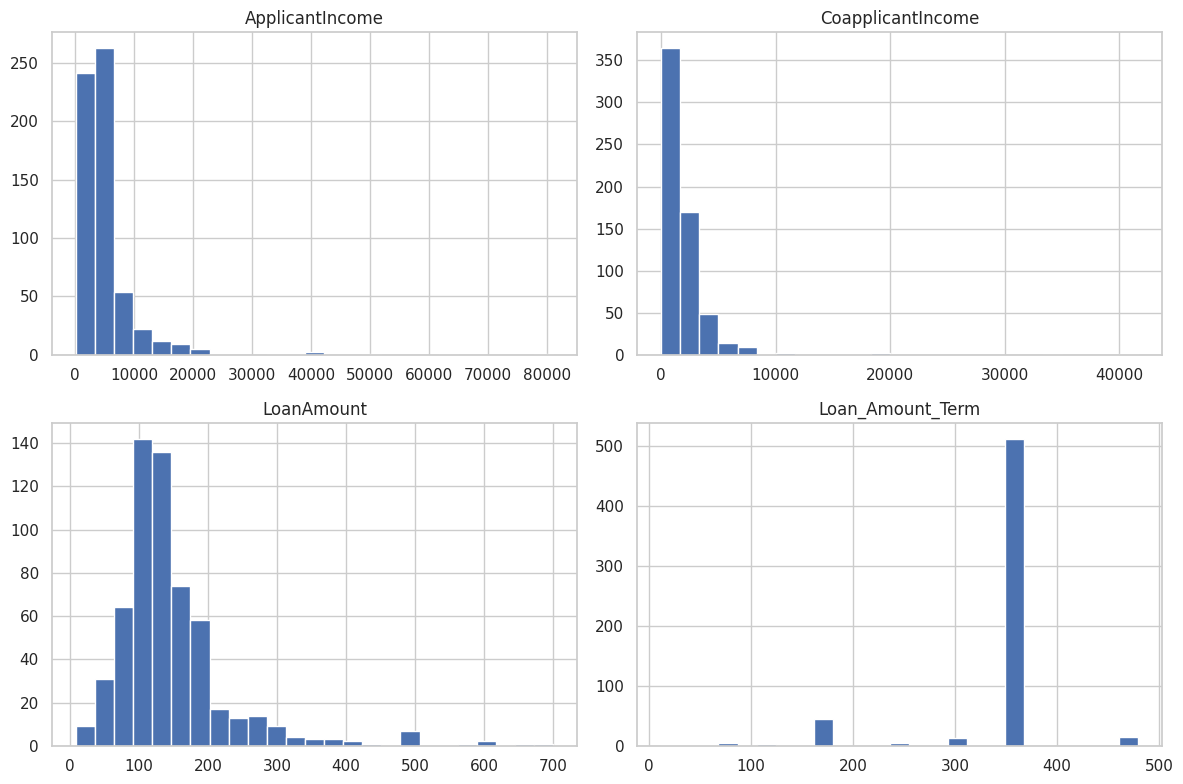

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0


In [3]:
sns.set_theme(style="whitegrid")

target_counts = train["Loan_Status"].value_counts()
print("Loan status distribution:")
display(target_counts.to_frame("Count").assign(Percent=(target_counts/len(train)*100).round(2)))

fig, ax = plt.subplots(figsize=(6,4))
train["Loan_Status"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Loan Status Distribution")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR/"01_target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

categorical_cols = ["Gender","Married","Dependents","Education","Self_Employed","Credit_History","Property_Area"]
numerical_cols = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()
for i, col in enumerate(categorical_cols):
    train[col].value_counts(dropna=False).plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=25)
for j in range(len(categorical_cols), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR/"02_categorical_univariate.png", dpi=120, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numerical_cols):
    ax.hist(train[col].dropna(), bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIG_DIR/"03_numerical_univariate.png", dpi=120, bbox_inches="tight")
plt.show()

display(train[numerical_cols].describe().T)


### 5.2 Bivariate Analysis

Each major predictor is compared with `Loan_Status`. For categorical variables, approval rates are useful because raw counts can be misleading when category sizes differ. Numerical variables are compared by approval status.

Approval rate by Gender (%):


Loan_Status,N,Y
Gender,,
Female,33.04,66.96
Male,30.67,69.33


Approval rate by Married (%):


Loan_Status,N,Y
Married,,
No,37.09,62.91
Yes,28.39,71.61


Approval rate by Dependents (%):


...

Loan_Status,N,Y
Self_Employed,,
No,31.40,68.60
Yes,31.71,68.29


Approval rate by Credit_History (%):


Loan_Status,N,Y
Credit_History,,
0.0,92.13,7.87
1.0,20.42,79.58


Approval rate by Property_Area (%):


Loan_Status,N,Y
Property_Area,,
Rural,38.55,61.45
Semiurban,23.18,76.82
Urban,34.16,65.84


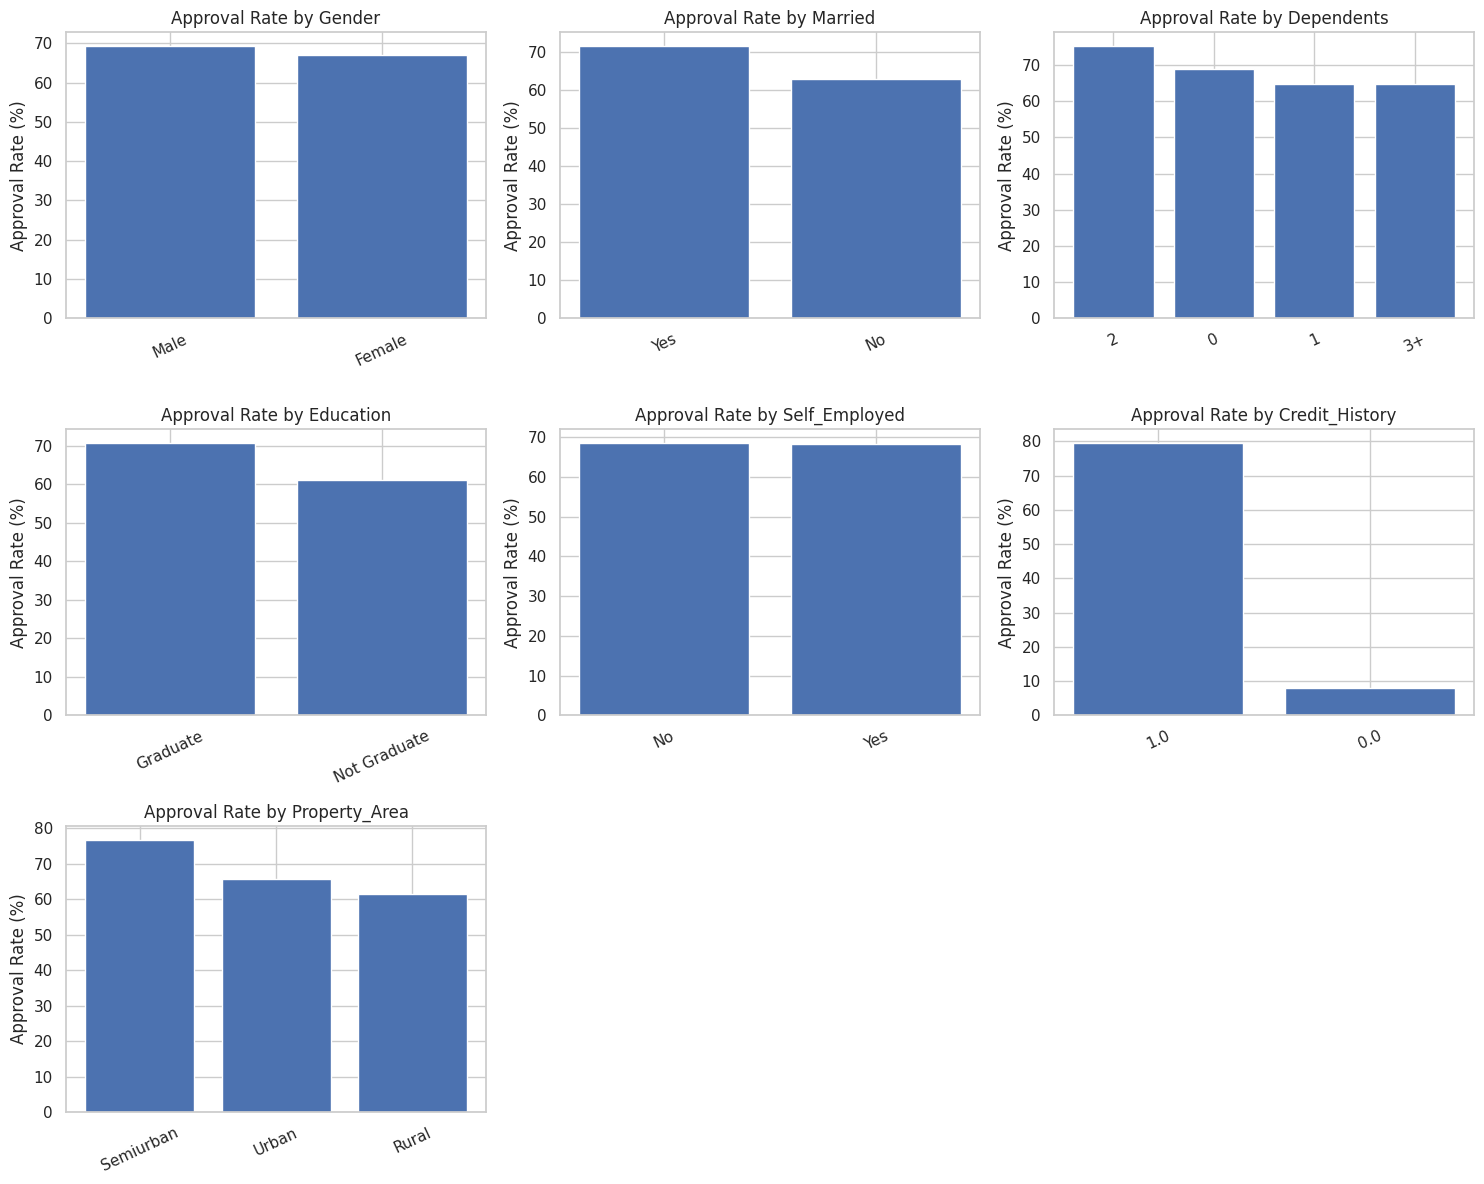

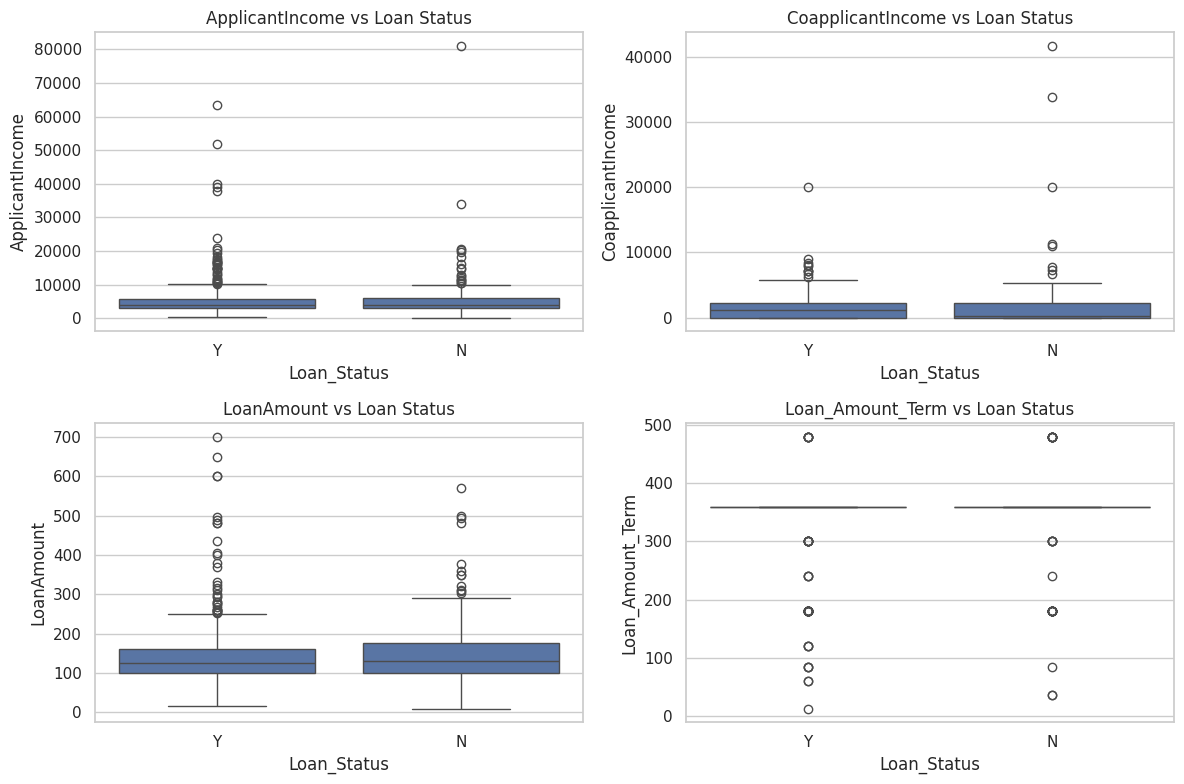

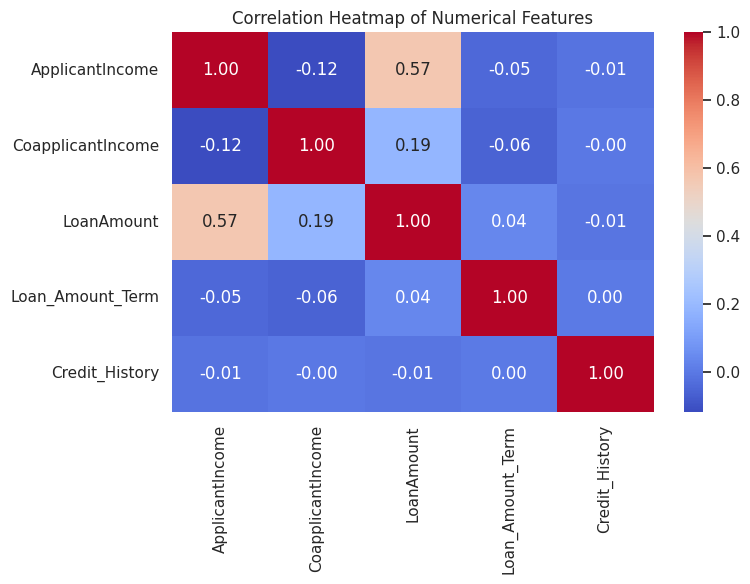

In [4]:
# Approval rates for categorical features
approval_tables = {}
for col in categorical_cols:
    table = pd.crosstab(train[col], train["Loan_Status"], normalize="index") * 100
    approval_tables[col] = table
    print(f"Approval rate by {col} (%):")
    display(table.round(2))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for i, col in enumerate(categorical_cols):
    rate = train.groupby(col)["Loan_Status"].apply(lambda s: (s=="Y").mean()*100).sort_values(ascending=False)
    axes[i].bar(rate.index.astype(str), rate.values)
    axes[i].set_title(f"Approval Rate by {col}")
    axes[i].set_ylabel("Approval Rate (%)")
    axes[i].tick_params(axis="x", rotation=25)
for j in range(len(categorical_cols), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR/"04_categorical_bivariate.png", dpi=120, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numerical_cols):
    sns.boxplot(data=train, x="Loan_Status", y=col, ax=ax)
    ax.set_title(f"{col} vs Loan Status")
plt.tight_layout()
plt.savefig(FIG_DIR/"05_numerical_bivariate.png", dpi=120, bbox_inches="tight")
plt.show()

# Correlation heatmap
corr_cols = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]
corr = train[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig(FIG_DIR/"06_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Missing Value and Outlier Treatment

**Categorical missing values:** imputed with the most frequent category (mode), because these fields are nominal and a simple mode replacement preserves the observed category vocabulary.

**Numerical missing values:** imputed with the median, because income/loan variables are skewed and the median is less sensitive to extreme observations than the mean.

**Outliers/skew:** financial variables are right-skewed. Rather than deleting valid applicants, the workflow uses `log1p` transformations for loan/income-derived variables. This compresses large values while retaining all observations. The original `LoanAmount` is specifically log-transformed as requested.

All imputers and encoders are inside a scikit-learn `Pipeline`/`ColumnTransformer`, so they are fitted only on the training folds. This prevents data leakage.

,Skew Before,Skew After log1p
ApplicantIncome,6.540,0.482
CoapplicantIncome,7.492,-0.173
LoanAmount,2.678,-0.150


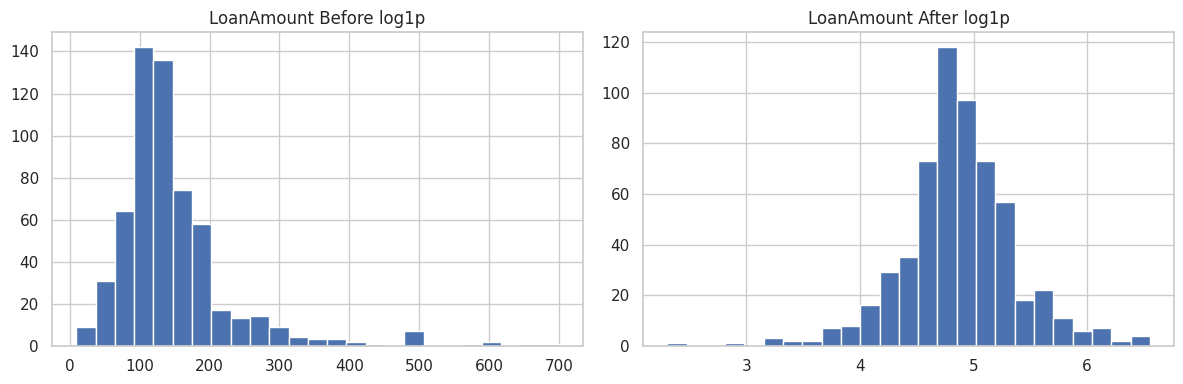

In [5]:
# Quantify skew before log transformation
skew_before = train[["ApplicantIncome","CoapplicantIncome","LoanAmount"]].skew()
log_demo = train[["ApplicantIncome","CoapplicantIncome","LoanAmount"]].copy()
for c in log_demo.columns:
    log_demo[c] = np.log1p(log_demo[c].clip(lower=0))
skew_after = log_demo.skew()
display(pd.DataFrame({"Skew Before": skew_before, "Skew After log1p": skew_after}).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(train["LoanAmount"].dropna(), bins=25)
axes[0].set_title("LoanAmount Before log1p")
axes[1].hist(np.log1p(train["LoanAmount"].dropna().clip(lower=0)), bins=25)
axes[1].set_title("LoanAmount After log1p")
plt.tight_layout()
plt.savefig(FIG_DIR/"07_loanamount_log_transform.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Evaluation Metrics for a Classification Problem

- **Accuracy:** proportion of all predictions that are correct.
- **Precision:** among predicted approvals, proportion that are actually approvals.
- **Recall:** among actual approvals, proportion correctly identified.
- **F1-score:** harmonic mean of precision and recall.
- **ROC-AUC:** measures ranking/discrimination across classification thresholds.
- **Confusion matrix:** counts true positives, true negatives, false positives and false negatives.

Because the target has more approvals than non-approvals, accuracy alone is not sufficient. The project therefore reports all requested metrics and uses stratified validation.

In [6]:
def metric_row(y_true, pred, prob):
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, prob)
    }

y = (train["Loan_Status"] == "Y").astype(int)
X = train.drop(columns=["Loan_Status"])
X_test_original = test.copy()

print("Positive class rate (Loan_Status=Y):", round(y.mean(), 4))
print("Negative class rate (Loan_Status=N):", round(1-y.mean(), 4))


Positive class rate (Loan_Status=Y): 0.6873
Negative class rate (Loan_Status=N): 0.3127


## 8. Model Building Part 1 — Baseline Models

Three required classification algorithms are evaluated first using the original features:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The split is stratified and uses `random_state=42`. Five-fold `StratifiedKFold` cross-validation is also used. Preprocessing is kept inside each pipeline to avoid leakage.

In [7]:
# Baseline preprocessing on original features
baseline_features = [c for c in X.columns if c != "Loan_ID"]
baseline_num = [c for c in baseline_features if X[c].dtype != "object"]
baseline_cat = [c for c in baseline_features if X[c].dtype == "object"]

baseline_pre = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), baseline_num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), baseline_cat)
])

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1)
}

X_train_b, X_valid_b, y_train_b, y_valid_b = train_test_split(
    X[baseline_features], y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

baseline_rows = []
baseline_fitted = {}
for name, model in baseline_models.items():
    pipe = Pipeline([("preprocessor", baseline_pre), ("model", model)])
    pipe.fit(X_train_b, y_train_b)
    pred = pipe.predict(X_valid_b)
    prob = pipe.predict_proba(X_valid_b)[:,1]
    m = metric_row(y_valid_b, pred, prob)
    cv_scores = cross_validate(
        pipe, X[baseline_features], y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring=["accuracy","precision","recall","f1","roc_auc"], n_jobs=1
    )
    m.update({
        "CV Accuracy Mean": cv_scores["test_accuracy"].mean(),
        "CV Precision Mean": cv_scores["test_precision"].mean(),
        "CV Recall Mean": cv_scores["test_recall"].mean(),
        "CV F1 Mean": cv_scores["test_f1"].mean(),
        "CV ROC-AUC Mean": cv_scores["test_roc_auc"].mean()
    })
    m["Model"] = name
    baseline_rows.append(m)
    baseline_fitted[name] = pipe

baseline_results = pd.DataFrame(baseline_rows).set_index("Model")
display(baseline_results.round(4))


,Accuracy,Precision,Recall,F1,ROC-AUC,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean
Model,,,,,,,,,,
Logistic Regression,0.8618,0.8400,0.9882,0.9081,0.8523,0.8030,0.7901,0.9716,0.8714,0.7509
Decision Tree,0.7561,0.8235,0.8235,0.8235,0.7144,0.6922,0.7767,0.7748,0.7753,0.6426
Random Forest,0.8211,0.8462,0.9059,0.8750,0.7861,0.7720,0.7869,0.9171,0.8469,0.7575


## 9. Feature Engineering

The engineered dataset adds:

- **TotalIncome** = ApplicantIncome + CoapplicantIncome.
- **EMI** = estimated monthly repayment from LoanAmount and Loan_Amount_Term using a fixed illustrative monthly rate of 1%/12; it is used as a relative affordability feature, not as a contractual interest-rate estimate.
- **BalanceIncome** = TotalIncome − EMI.
- `log1p` versions of income, loan amount and derived financial variables to reduce skew.
- **Dependents_num** converts `3+` to 3 while preserving missing values.

`Loan_ID`, the two raw income components, and raw `Dependents` are removed after engineering because the engineered variables carry the intended combined/ordinal information. Missing-value imputation and encoding still happen inside the modeling pipeline.

In [8]:
def engineer_features(df):
    df = df.copy()
    df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
    term = df["Loan_Amount_Term"].replace(0, np.nan)
    monthly_rate = 0.01 / 12
    df["EMI"] = (
        df["LoanAmount"] * 1000 * monthly_rate * (1 + monthly_rate) ** term
        / ((1 + monthly_rate) ** term - 1)
    )
    df["BalanceIncome"] = df["TotalIncome"] - df["EMI"]

    for col in ["ApplicantIncome","CoapplicantIncome","LoanAmount","TotalIncome","EMI","BalanceIncome"]:
        df["Log_" + col] = np.log1p(df[col].clip(lower=0))

    df["Dependents_num"] = df["Dependents"].replace({"3+": 3}).astype(float)
    df = df.drop(columns=["Loan_ID","ApplicantIncome","CoapplicantIncome","Dependents"], errors="ignore")
    return df

X_engineered = engineer_features(X)
X_test_engineered = engineer_features(X_test_original)

print("Engineered feature count:", X_engineered.shape[1])
display(X_engineered.head())


Engineered feature count: 18


,Gender,Married,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,EMI,BalanceIncome,Log_ApplicantIncome,Log_CoapplicantIncome,Log_LoanAmount,Log_TotalIncome,Log_EMI,Log_BalanceIncome,Dependents_num
0,Male,No,Graduate,No,NaN,360.0,1.0,Urban,5849.0,NaN,NaN,8.674197,0.000000,NaN,8.674197,NaN,NaN,0.0
1,Male,Yes,Graduate,No,128.0,360.0,1.0,Rural,6091.0,411.698586,5679.301414,8.430327,7.319202,4.859812,8.714732,6.022718,8.644760,1.0
2,Male,Yes,Graduate,Yes,66.0,360.0,1.0,Urban,3000.0,212.282083,2787.717917,8.006701,0.000000,4.204693,8.006701,5.362616,7.933337,0.0
3,Male,Yes,Not Graduate,No,120.0,360.0,1.0,Urban,4941.0,385.967425,4555.032575,7.857094,7.765993,4.795791,8.505525,5.958341,8.424207,0.0
4,Male,No,Graduate,No,141.0,360.0,1.0,Urban,6000.0,453.511724,5546.488276,8.699681,0.000000,4.955827,8.699681,6.119224,8.621101,0.0


## 10. Model Building Part 2 — Tuning and Final Comparison

The engineered features are evaluated using the same stratified 80/20 validation split. `RandomizedSearchCV` uses five stratified folds and ROC-AUC as its tuning objective. The search is intentionally modest because the dataset is small.

The final model is selected using the combined evidence from held-out validation metrics and cross-validation. No test-set labels are used because the supplied test file has no target.

In [9]:
eng_num = [c for c in X_engineered.columns if X_engineered[c].dtype != "object"]
eng_cat = [c for c in X_engineered.columns if X_engineered[c].dtype == "object"]

eng_pre = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), eng_num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), eng_cat)
])

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {"model__C":[0.01,0.1,1,10], "model__solver":["liblinear"]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"model__max_depth":[2,3,4,5,6,None],
         "model__min_samples_split":[2,5,10],
         "model__min_samples_leaf":[1,2,4]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
        {"model__n_estimators":[50,100],
         "model__max_depth":[None,4,6,8],
         "model__min_samples_split":[2,5],
         "model__min_samples_leaf":[1,2],
         "model__max_features":["sqrt","log2"]}
    )
}

X_train, X_valid, y_train, y_valid = train_test_split(
    X_engineered, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_rows = []
tuned_models = {}

for name, (model, params) in models.items():
    pipe = Pipeline([("preprocessor", eng_pre), ("model", model)])
    n_total = int(np.prod([len(v) for v in params.values()]))
    search = RandomizedSearchCV(
        pipe, params, n_iter=min(4, n_total), scoring="roc_auc",
        cv=cv, random_state=RANDOM_STATE, n_jobs=1, refit=True
    )
    search.fit(X_train, y_train)

    pred = search.predict(X_valid)
    prob = search.predict_proba(X_valid)[:,1]
    m = metric_row(y_valid, pred, prob)

    m.update({
        "CV ROC-AUC Mean": search.best_score_,
        "Best Params": str(search.best_params_)
    })
    m["Model"] = name
    tuned_rows.append(m)
    tuned_models[name] = search

tuned_results = pd.DataFrame(tuned_rows).set_index("Model")
display(tuned_results.round(4))


,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC Mean,Best Params
Model,,,,,,,
Logistic Regression,0.8537,0.8317,0.9882,0.9032,0.8498,0.7208,"{'model__solver': 'liblinear', 'model__C': 0.01}"
Decision Tree,0.7642,0.9000,0.7412,0.8129,0.8204,0.6972,"{'model__min_samples_split': 5, 'model__min_sa..."
Random Forest,0.8618,0.8864,0.9176,0.9017,0.8293,0.7648,"{'model__n_estimators': 50, 'model__min_sample..."


,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC Mean
Model,,,,,,
Logistic Regression,0.8537,0.8317,0.9882,0.9032,0.8498,0.7208
Decision Tree,0.7642,0.9000,0.7412,0.8129,0.8204,0.6972
Random Forest,0.8618,0.8864,0.9176,0.9017,0.8293,0.7648


Selected best model: Random Forest
Best parameters: {'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}

Classification report:
              precision    recall  f1-score   support

           N       0.80      0.74      0.77        38
           Y       0.89      0.92      0.90        85

    accuracy                           0.86       123
   macro avg       0.84      0.83      0.83       123
weighted avg       0.86      0.86      0.86       123



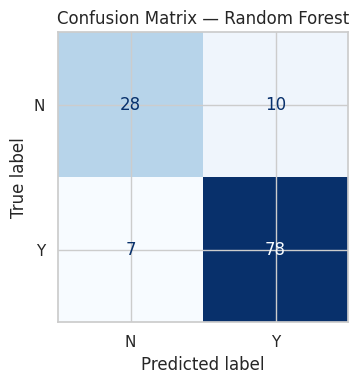

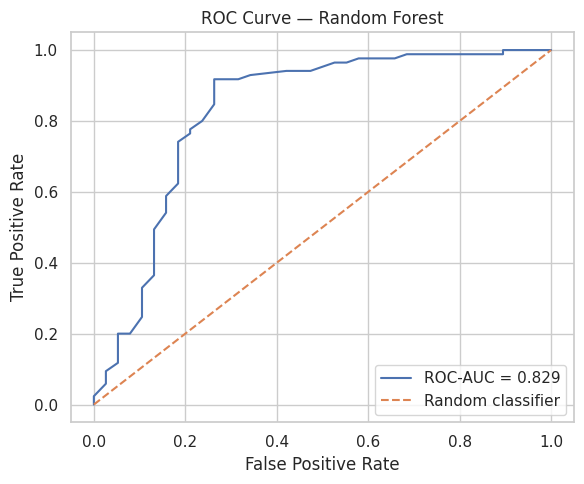

In [10]:
comparison = tuned_results[[
    "Accuracy","Precision","Recall","F1","ROC-AUC","CV ROC-AUC Mean"
]].copy()
display(comparison.round(4))

best_name = tuned_results["CV ROC-AUC Mean"].idxmax()
best_search = tuned_models[best_name]
print("Selected best model:", best_name)
print("Best parameters:", best_search.best_params_)

# Validation confusion matrix and ROC curve for the selected model
best_pred = best_search.predict(X_valid)
best_prob = best_search.predict_proba(X_valid)[:,1]

print("\nClassification report:")
print(classification_report(y_valid, best_pred, target_names=["N","Y"]))

cm = confusion_matrix(y_valid, best_pred)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm, display_labels=["N","Y"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig(FIG_DIR/"08_best_model_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

fpr, tpr, _ = roc_curve(y_valid, best_prob)
auc_value = roc_auc_score(y_valid, best_prob)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.3f}")
ax.plot([0,1],[0,1],"--", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — {best_name}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"09_best_model_roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()


### Feature Importance

For Logistic Regression, the absolute value of the fitted coefficients is used as a measure of feature influence after preprocessing. For tree models, `feature_importances_` can be used. This project reports the appropriate importance measure for the selected model.

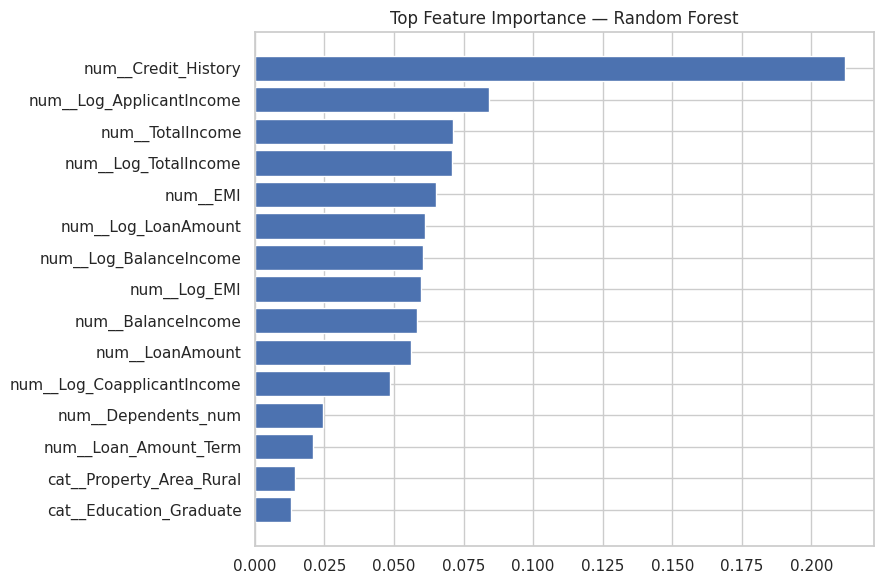

,Feature,Importance
2,num__Credit_History,0.2119
6,num__Log_ApplicantIncome,0.0842
3,num__TotalIncome,0.0713
9,num__Log_TotalIncome,0.0708
4,num__EMI,0.0653
8,num__Log_LoanAmount,0.0611
11,num__Log_BalanceIncome,0.0606
10,num__Log_EMI,0.0599
5,num__BalanceIncome,0.0584
0,num__LoanAmount,0.0561


In [11]:
fitted_pre = best_search.best_estimator_.named_steps["preprocessor"]
fitted_model = best_search.best_estimator_.named_steps["model"]
feature_names = fitted_pre.get_feature_names_out()

if hasattr(fitted_model, "coef_"):
    importance = np.abs(fitted_model.coef_[0])
else:
    importance = fitted_model.feature_importances_

fi = pd.DataFrame({"Feature": feature_names, "Importance": importance})
fi = fi.sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9,6))
fi_sorted = fi.sort_values("Importance")
ax.barh(fi_sorted["Feature"], fi_sorted["Importance"])
ax.set_title(f"Top Feature Importance — {best_name}")
plt.tight_layout()
plt.savefig(FIG_DIR/"10_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

display(fi.round(4))


## 11. Predict on the Test Set and Save `submission.csv`

The selected model is refit on **all labeled training data** using the best hyperparameters found during tuning. The test set is then transformed by the same fitted preprocessing and predicted. The final file contains exactly two columns: `Loan_ID` and `Loan_Status` (`Y`/`N`).

In [12]:
final_model = best_search.best_estimator_
final_model.fit(X_engineered, y)

test_pred_num = final_model.predict(X_test_engineered)
test_pred = np.where(test_pred_num == 1, "Y", "N")

submission = pd.DataFrame({
    "Loan_ID": test["Loan_ID"],
    "Loan_Status": test_pred
})
submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Submission shape:", submission.shape)
display(submission.head(10))
print("\nPrediction distribution:")
display(submission["Loan_Status"].value_counts().to_frame("Count"))


Saved: outputs/submission.csv
Submission shape: (367, 2)


,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y
5,LP001054,Y
6,LP001055,Y
7,LP001056,N
8,LP001059,Y
9,LP001067,Y



Prediction distribution:


,Count
Loan_Status,
Y,292
N,75


## 12. Conclusion, Limitations, and Future Work

### Conclusion
The project follows a leakage-safe classification workflow from EDA through feature engineering, stratified validation, hyperparameter tuning and final test prediction. The selected model is based on validation and cross-validation evidence rather than test-set outcomes.

### Limitations
- The dataset is relatively small (614 labeled records), so validation estimates have uncertainty.
- `Credit_History` is influential but contains missing values, so imputation is necessary.
- The EMI feature uses an illustrative fixed rate of 1%/12 because the dataset does not provide an applicant-specific interest rate; it should therefore be interpreted as a relative engineered feature.
- The test set has no ground-truth labels in the supplied files, so true test accuracy cannot be calculated here.
- This model should support, not replace, responsible lending review. Real deployment would require fairness, explainability, monitoring, governance, and policy validation.

### Future Work
- Test calibrated probabilities and threshold optimization.
- Evaluate additional algorithms such as gradient boosting.
- Use repeated cross-validation or bootstrap confidence intervals.
- Add fairness analysis across relevant applicant groups.
- Monitor drift and retrain using newly labeled applications.
- Validate the model prospectively before operational use.

In [13]:
# Final reproducibility summary
best_metrics = metric_row(y_valid, best_pred, best_prob)
print("BEST MODEL:", best_name)
print("Validation metrics:")
for k,v in best_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nRepository outputs created:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(p)


BEST MODEL: Random Forest
Validation metrics:
Accuracy: 0.8618
Precision: 0.8864
Recall: 0.9176
F1: 0.9017
ROC-AUC: 0.8293

Repository outputs created:
outputs/figures/01_target_distribution.png
outputs/figures/02_categorical_univariate.png
outputs/figures/03_numerical_univariate.png
outputs/figures/04_categorical_bivariate.png
outputs/figures/05_numerical_bivariate.png
outputs/figures/06_correlation_heatmap.png
outputs/figures/07_loanamount_log_transform.png
outputs/figures/08_best_model_confusion_matrix.png
outputs/figures/09_best_model_roc_curve.png
outputs/figures/10_feature_importance.png
outputs/submission.csv
